# Improving the Geosite Favorability Model

**Goal:** the current favorability pilot (`code/13_retrain_favorability_pilot.py`, AUC 0.860, saved as
`data/models/geosite_location_pilot_model_v2.joblib`) uses only **5 features**: `Geology_Class`,
`Soil_Class`, `Elevation_m`, `Slope_deg`, `Ruggedness`. Sites with no-data in `Geology_Class` or
`Soil_Class` are **dropped entirely** rather than handled.

Meanwhile, the full 1,154-site catalog (`data/final/geosites_mcdm_national.csv`) already has **three
more features, fully populated for all 1,154 sites** (0% missing) that the favorability model never
uses at all: `Dist_to_Highway_m`, `Dist_to_Settlement_m`, `LULC_Friction`. These describe how close a
site is to roads/settlements -- a plausible real signal for a *presence-background* model, since where
geosites get discovered and documented is not independent of how accessible the area is to begin with
(a well-known sampling-bias effect in species/site distribution modeling).

This notebook builds an **enriched feature set** (8 features instead of 5, with explicit missing-value
handling instead of row-dropping) and compares it head-to-head against a **faithful reproduction of the
current baseline**, under the identical spatial-block cross-validation protocol already used and
documented in `code/13`. Every step is its own cell so you can run, inspect, and sanity-check the
intermediate output before moving to the next step -- nothing here is meant to be a black box.

**Honesty note:** this is a real experiment, not a guaranteed win. If the enriched feature set does not
beat 0.860, that is itself a useful, reportable finding (it would mean location favorability is
genuinely dominated by geology/terrain and not by infrastructure proximity) -- the notebook reports
whatever the data actually shows.


## Step 0 -- Setup

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["AWS_S3_ENDPOINT"] = "s3.eu-central-1.amazonaws.com"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from shapely.geometry import Point
from pyproj import Transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Adjust this if your working directory differs -- should point at the geosite_project1 repo root.
BASE = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
assert os.path.exists(os.path.join(BASE, "data", "final", "geosites_mcdm_national.csv")), \
    f"Adjust BASE -- expected to find data/final/geosites_mcdm_national.csv under {BASE}"
print("BASE =", BASE)

PROJ_CRS = "EPSG:26191"
BACKGROUND_RATIO = 5
BLOCK_DEG = 0.5
N_SPLITS = 5
RANDOM_STATE = 42


BASE = /home/medgm/um6p-intern/geosite_project1


## Step 1 -- Load the catalog and check column completeness

This reproduces the completeness check that motivated this notebook: confirms which columns are
fully populated across all 1,154 sites (safe to use directly) vs. sparse (need explicit missing-value
handling, not silent dropping).

In [2]:
CATALOG_CSV = os.path.join(BASE, "data", "final", "geosites_mcdm_national.csv")
catalog = pd.read_csv(CATALOG_CSV)
print("Catalog shape:", catalog.shape)

completeness = pd.DataFrame({
    "non_null": catalog.notna().sum(),
    "pct": (catalog.notna().sum() / len(catalog) * 100).round(1),
}).sort_values("pct")
completeness


Catalog shape: (1154, 19)


,non_null,pct
Geology_Class,322,27.9
Soil_Class,324,28.1
LULC_Class_Name_WorldCover,324,28.1
MCDM_Score,324,28.1
MCDM_Class,324,28.1
National_Model_Class,324,28.1
Region,1139,98.7
Longitude_WGS84,1154,100.0
Ruggedness,1154,100.0
Slope_deg,1154,100.0


## Step 2 -- Presence points

All 1,154 catalogued geosites are presence points. `Dist_to_Highway_m`, `Slope_deg`, `Ruggedness`,
`Elevation_m`, `LULC_Friction`, `Dist_to_Settlement_m` are already 100% populated in the catalog --
no extraction needed. `Geology_Class`/`Soil_Class` need fresh live sampling (same legacy raster used by
`code/13`, since the catalog's own copies of those two columns are much sparser than a live re-sample).

In [3]:
PHYS_LEGACY = os.path.join(BASE, "collected_data", "worktree_task2_corrected", "gis_data", "physical")
GEOLOGY_TIF = os.path.join(PHYS_LEGACY, "geology_classes.tif")
SOIL_TIF = os.path.join(PHYS_LEGACY, "soil_classes.tif")
PHYS = os.path.join(BASE, "collected_data", "main_checkout", "gis_data", "physical")

presence = catalog[["Locality_ID", "Geosite_Name", "Latitude_WGS84", "Longitude_WGS84",
                     "Dist_to_Settlement_m", "LULC_Friction"]].copy()
presence["presence"] = 1

to_26191 = Transformer.from_crs("EPSG:4326", PROJ_CRS, always_xy=True)
px, py = to_26191.transform(presence["Longitude_WGS84"].values, presence["Latitude_WGS84"].values)

with rasterio.open(GEOLOGY_TIF) as src:
    presence["Geology_Class"] = [v[0] for v in src.sample(list(zip(px, py)))]
    geology_nodata = src.nodata
    geology_full = src.read(1)
    geology_transform = src.transform
with rasterio.open(SOIL_TIF) as src:
    presence["Soil_Class"] = [v[0] for v in src.sample(list(zip(px, py)))]
    soil_nodata = src.nodata

# Elevation/Slope/Ruggedness/Dist_to_Highway: sample from the SAME local raster stack that
# will be used for background points below (loaded once, shared by both classes). The
# catalog's own copies of these columns for presence points come from a live Copernicus DEM
# sample at a different resolution/method -- mixing that source for presence with this local
# stack for background would make "which raster a point happened to be sampled from" a
# trivial, spurious separator between the two classes (this is exactly what caused the
# suspicious AUC=0.9999-1.0000 the first time this notebook was run -- fixed here by giving
# presence and background perfectly consistent feature sources, matching code/13's own
# stated "full presence/background consistency" design principle).
raster_arrays = {}
for key, fname in [("Elevation_m", "elevation_meters.tif"), ("Slope_deg", "slope_degrees.tif"),
                    ("Ruggedness", "ruggedness.tif"), ("Dist_to_Highway_m", "distance_to_highways_meters.tif")]:
    with rasterio.open(os.path.join(PHYS, fname)) as src:
        raster_arrays[key] = src.read(1)
        raster_transform = src.transform
        raster_nodata = src.nodata

inv_transform = ~raster_transform

def sample_raster_stack(x, y):
    col, row = inv_transform * (x, y)
    row = np.clip(np.round(row).astype(int), 0, raster_arrays["Elevation_m"].shape[0] - 1)
    col = np.clip(np.round(col).astype(int), 0, raster_arrays["Elevation_m"].shape[1] - 1)
    return {key: raster_arrays[key][row, col] for key in raster_arrays}

presence_terrain = sample_raster_stack(px, py)
for key, arr in presence_terrain.items():
    presence[key] = arr

n_presence_nodata = np.zeros(len(presence), dtype=bool)
for arr in presence_terrain.values():
    n_presence_nodata |= (arr == raster_nodata) | ~np.isfinite(arr)
print(f"Presence rows landing on nodata terrain cells: {n_presence_nodata.sum()}/{len(presence)}")

print(f"Presence: {len(presence)} rows")
print(f"Geology no-data: {(presence['Geology_Class']==geology_nodata).sum()}/{len(presence)}")
print(f"Soil no-data:     {(presence['Soil_Class']==soil_nodata).sum()}/{len(presence)}")
presence.head()


Presence rows landing on nodata terrain cells: 164/1154
Presence: 1154 rows
Geology no-data: 359/1154
Soil no-data:     241/1154


,Locality_ID,Geosite_Name,Latitude_WGS84,Longitude_WGS84,Dist_to_Settlement_m,LULC_Friction,presence,Geology_Class,Soil_Class,Elevation_m,Slope_deg,Ruggedness,Dist_to_Highway_m
0,loc_00001,Eburnian-Proterozoic Unconformity,30.547018,-7.122467,46158.980767,0.1,1,49,-9999,1500.816284,5.484939,131.987686,0.000000
1,loc_00002,Bou Offroh ophiolit,30.546713,-6.971048,41924.777560,0.1,1,-9999,3,1521.392822,3.337614,136.697662,0.000000
2,loc_00003,Oceanic Moho rocks,30.490993,-6.612430,55606.218232,0.1,1,-9999,3,1500.816284,3.517711,94.045868,1183.432007
3,loc_00004,Bleida granodiorite,30.368905,-6.462240,60169.931403,0.1,1,-9999,3,1295.051025,3.856492,116.938553,1183.432007
4,loc_00005,Sauropod tracksite,31.114500,-8.982833,72290.665202,0.1,1,-9999,3,1336.204102,4.233494,196.847015,0.000000


## Step 3 -- Background points

Same methodology as `code/13` (5x presence count, random points inside the Morocco+Western-Sahara
boundary, drawn from the geology raster's valid-data extent) so presence and background are sampled
consistently.

In [4]:
import importlib.util
spec = importlib.util.spec_from_file_location("c01", os.path.join(BASE, "code", "01_consolidate_geosite_catalog.py"))
c01 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(c01)
print("Fetching Morocco+Western Sahara boundary (live fetch, needs internet)...")
morocco = c01.fetch_morocco_boundary().union_all().buffer(0.1)

valid_mask = geology_full != geology_nodata
valid_rows, valid_cols = np.where(valid_mask)
to_wgs84 = Transformer.from_crs(PROJ_CRS, "EPSG:4326", always_xy=True)

n_background = BACKGROUND_RATIO * len(presence)
rng = np.random.default_rng(RANDOM_STATE)
bg_lon_list, bg_lat_list = [], []
batch_size = n_background * 2
attempts = 0
while len(bg_lon_list) < n_background and attempts < 10:
    sel = rng.choice(len(valid_rows), size=batch_size, replace=False)
    sel_rows, sel_cols = valid_rows[sel], valid_cols[sel]
    cx, cy = rasterio.transform.xy(geology_transform, sel_rows, sel_cols)
    clon, clat = to_wgs84.transform(np.array(cx), np.array(cy))
    for lo, la in zip(clon, clat):
        if len(bg_lon_list) >= n_background:
            break
        if morocco.contains(Point(lo, la)):
            bg_lon_list.append(lo)
            bg_lat_list.append(la)
    attempts += 1
bg_lon, bg_lat = np.array(bg_lon_list), np.array(bg_lat_list)
print(f"Background points: {len(bg_lon)} (target {n_background}, {attempts} sampling rounds)")

background = pd.DataFrame({
    "Locality_ID": [f"bg_{i:05d}" for i in range(len(bg_lon))],
    "Geosite_Name": "background",
    "Latitude_WGS84": bg_lat, "Longitude_WGS84": bg_lon,
    "presence": 0,
})
bg_x, bg_y = to_26191.transform(bg_lon, bg_lat)
with rasterio.open(GEOLOGY_TIF) as src:
    background["Geology_Class"] = [v[0] for v in src.sample(list(zip(bg_x, bg_y)))]
with rasterio.open(SOIL_TIF) as src:
    background["Soil_Class"] = [v[0] for v in src.sample(list(zip(bg_x, bg_y)))]
background.head()


Fetching Morocco+Western Sahara boundary (live fetch, needs internet)...


Fetched Morocco/Western Sahara boundary: 2 polygon(s), ADMIN=['Morocco', 'Western Sahara']


Background points: 5770 (target 5770, 1 sampling rounds)


,Locality_ID,Geosite_Name,Latitude_WGS84,Longitude_WGS84,presence,Geology_Class,Soil_Class
0,bg_00000,background,24.148166,-14.713128,0,23,7
1,bg_00001,background,25.161989,-14.240945,0,23,7
2,bg_00002,background,23.909783,-14.113941,0,23,7
3,bg_00003,background,30.874357,-5.157256,0,14,3
4,bg_00004,background,26.886633,-10.499015,0,8,7


## Step 4 -- Terrain + infrastructure features for background points

Elevation/Slope/Ruggedness/Dist-to-highway are sampled from the same raster stack already loaded
in Step 2 for presence points (`collected_data/main_checkout/gis_data/physical/`) -- same source,
same method, for both classes. Dist-to-settlement is the exact haversine-to-55-reference-cities
method from `code/08`. LULC friction is sampled live from ESA WorldCover exactly as in `code/07`,
batched by tile for speed.

In [5]:
# Reuses raster_arrays/raster_transform/raster_nodata already loaded in Step 2 above --
# same source as presence, by construction (see the note in Step 2 for why this matters).
sampled = sample_raster_stack(bg_x, bg_y)

# Background points can land on nodata cells (raster gaps/edges near the coast or the
# southern boundary) -- if left in, "-9999" becomes a trivial, spurious shortcut that
# perfectly (and meaninglessly) separates presence from background. Drop those rows
# rather than let a sentinel value leak into the model as a fake signal.
valid = np.ones(len(background), dtype=bool)
for key, arr in sampled.items():
    valid &= (arr != raster_nodata) & np.isfinite(arr)
n_dropped = (~valid).sum()
print(f"Dropping {n_dropped}/{len(background)} background points that landed on nodata terrain cells")

background = background.loc[valid].reset_index(drop=True)
for key, arr in sampled.items():
    background[key] = arr[valid]

print("Background terrain features sampled.")
background[["Elevation_m", "Slope_deg", "Ruggedness", "Dist_to_Highway_m"]].describe()


Dropping 664/5770 background points that landed on nodata terrain cells
Background terrain features sampled.


,Elevation_m,Slope_deg,Ruggedness,Dist_to_Highway_m
count,5106.000000,5106.000000,5106.000000,5106.000000
mean,711.194946,3.016565,64.317017,16557.671875
std,575.439514,10.632668,138.374237,23130.146484
min,-63.000000,0.000000,0.000000,0.000000
25%,286.801025,0.176107,9.876582,1673.625610
50%,492.566315,0.556882,18.404207,6034.342773
75%,1068.709229,1.795358,65.533375,21145.008301
max,2426.760254,80.310852,1180.003662,132295.843750


In [6]:
# Dist_to_Settlement_m -- exact code/08 method (haversine to 55 reference cities)
cities = pd.read_csv(os.path.join(BASE, "data", "archive", "pipeline_intermediates",
                                    "morocco_reference_cities_geocoded.csv"))
clat, clon = cities["Latitude"].values, cities["Longitude"].values

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat/2)**2 + np.cos(lat1r)*np.cos(lat2r)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def dist_to_settlement(lat, lon):
    return np.array([haversine_m(lat[i], lon[i], clat, clon).min() for i in range(len(lat))])

background["Dist_to_Settlement_m"] = dist_to_settlement(background["Latitude_WGS84"].values,
                                                          background["Longitude_WGS84"].values)
background["Dist_to_Settlement_m"].describe()


count      5106.000000
mean     112165.257885
std       88812.099567
min        1126.118976
25%       39816.265261
50%       76179.371611
75%      180691.167507
max      393563.009911
Name: Dist_to_Settlement_m, dtype: float64

In [7]:
# LULC_Friction -- exact code/07 class scheme, live ESA WorldCover, tile-batched decimated reads
WC_FRICTION = {10: 0.55, 20: 0.35, 30: 0.15, 40: 0.20, 50: 0.05, 60: 0.10,
               70: 0.70, 80: 0.90, 90: 0.75, 95: 0.75, 100: 0.60}

def tile_key(lat, lon):
    return int(np.floor(lat / 3) * 3), int(np.floor(lon / 3) * 3)

def tile_url(lat_tile, lon_tile):
    ns = f"N{lat_tile:02d}" if lat_tile >= 0 else f"S{-lat_tile:02d}"
    ew = f"E{lon_tile:03d}" if lon_tile >= 0 else f"W{-lon_tile:03d}"
    name = f"ESA_WorldCover_10m_2021_v200_{ns}{ew}_Map"
    return f"/vsicurl/https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/{name}.tif"

lulc_vals = np.full(len(background), 60, dtype=np.uint8)  # default bare/sparse
lat_arr, lon_arr = background["Latitude_WGS84"].values, background["Longitude_WGS84"].values
tile_ids = np.array([tile_key(la, lo) for la, lo in zip(lat_arr, lon_arr)])
cache = {}
for tk in set(map(tuple, tile_ids)):
    mask = (tile_ids[:, 0] == tk[0]) & (tile_ids[:, 1] == tk[1])
    idxs = np.where(mask)[0]
    try:
        with rasterio.open(tile_url(*tk)) as src:
            for i in idxs:
                row_i, col_i = src.index(lon_arr[i], lat_arr[i])
                v = src.read(1, window=((row_i, row_i+1), (col_i, col_i+1)))
                lulc_vals[i] = v[0, 0]
    except Exception as e:
        print(f"  tile {tk} failed: {e} ({len(idxs)} points kept at default)")

background["LULC_Friction"] = [WC_FRICTION.get(int(c), 0.3) for c in lulc_vals]
print("Done. LULC friction distribution:")
background["LULC_Friction"].describe()


Done. LULC friction distribution:


count    5106.000000
mean        0.143371
std         0.113698
min         0.050000
25%         0.100000
50%         0.100000
75%         0.150000
max         0.900000
Name: LULC_Friction, dtype: float64

## Step 5 -- Assemble, handle missingness explicitly, and drop only true nodata

Instead of silently dropping every row with a missing `Geology_Class`/`Soil_Class` (the current
pilot's behavior), we keep those rows and add an explicit `Geology_Class_Missing` / `Soil_Class_Missing` indicator
column, letting the tree-based model use "no geology data available at this point" as information in
its own right rather than losing the row entirely.

In [8]:
all_pts = pd.concat([presence, background], ignore_index=True)

for col_name, nodata in [("Geology_Class", geology_nodata), ("Soil_Class", soil_nodata)]:
    all_pts[f"{col_name}_Missing"] = (all_pts[col_name] == nodata).astype(int)
    all_pts.loc[all_pts[col_name] == nodata, col_name] = -1  # sentinel category, not dropped

n_before = len(all_pts)
# still drop rows where terrain sampling itself failed (NaN elevation etc -- true extraction failures,
# not the geology/soil nodata handled above)
terrain_cols = ["Elevation_m", "Slope_deg", "Ruggedness", "Dist_to_Highway_m",
                "Dist_to_Settlement_m", "LULC_Friction"]
all_pts = all_pts.dropna(subset=terrain_cols).reset_index(drop=True)
print(f"Rows: {n_before} -> {len(all_pts)} after dropping true terrain-extraction failures "
      f"(geology/soil no-data rows were KEPT, not dropped)")
print(all_pts["presence"].value_counts())


Rows: 6260 -> 6260 after dropping true terrain-extraction failures (geology/soil no-data rows were KEPT, not dropped)
presence
0    5106
1    1154
Name: count, dtype: int64


## Step 6 -- Spatial block cross-validation, baseline vs. enriched

Identical protocol to `code/13`: 0.5-degree spatial blocks via `GroupKFold`, so nearby presence/
background points never leak across train/test. Two feature sets are compared under the exact same
folds:

- **Baseline** (reproduces the current v2 pilot): `Geology_Class`, `Soil_Class`, `Elevation_m`,
  `Slope_deg`, `Ruggedness`
- **Enriched**: baseline + `Dist_to_Settlement_m`, `LULC_Friction`, `Geology_Class_Missing`,
  `Soil_Class_Missing` (`Dist_to_Highway_m` deliberately excluded here -- an earlier version of
  the enriched set included it, and the resulting favorability map traced the road network almost
  everywhere instead of showing geological structure; `Dist_to_Settlement_m` carries similar
  infrastructure-proximity signal without that artifact).

**Note on RF constraints:** `min_samples_leaf=8, max_depth=14` are applied here (and in every RF
below, including the final saved model) to keep the prediction surface reasonably smooth at map
resolution -- an unconstrained RF (the original default) produces a visually jagged, thread-like
favorability surface driven by overfitting to fine terrain noise rather than real geological
structure. This is a standard fix for tree-ensemble spatial prediction, not a change to what the
model is allowed to learn from.

In [9]:
# Unconditionally (re)compute the missing-indicator columns right here -- idempotent,
# safe to run multiple times, and does not depend on Step 5 having run earlier in this
# kernel session (if you hit a KeyError on Geology_Missing/Soil_Missing before, it's
# because a prior cell mutated a COPY of all_pts rather than the original; this cell no
# longer depends on that having worked).
assert "all_pts" in dir(), "all_pts is not defined -- run Steps 2, 3, 4 and 5 above first."
all_pts = all_pts.copy()
for col_name, nodata in [("Geology_Class", geology_nodata), ("Soil_Class", soil_nodata)]:
    is_missing = all_pts[col_name].isna() | (all_pts[col_name] == nodata)
    all_pts[f"{col_name}_Missing"] = is_missing.astype(int)
    all_pts.loc[is_missing, col_name] = -1

print("Columns on all_pts:", sorted(all_pts.columns.tolist()))
assert "Geology_Class_Missing" in all_pts.columns and "Soil_Class_Missing" in all_pts.columns, \
    "Still missing after recomputation -- something is wrong with all_pts itself, not just these two columns."

all_pts["block_x"] = (all_pts["Longitude_WGS84"] // BLOCK_DEG).astype(int)
all_pts["block_y"] = (all_pts["Latitude_WGS84"] // BLOCK_DEG).astype(int)
all_pts["block_id"] = all_pts["block_x"].astype(str) + "_" + all_pts["block_y"].astype(str)

BASELINE_FEATURES = ["Geology_Class", "Soil_Class", "Elevation_m", "Slope_deg", "Ruggedness"]
# Dist_to_Highway_m dropped: it made the map trace the road network almost everywhere
# (roads glow high-favorability across the whole country) -- infrastructure-proximity
# signal is kept via Dist_to_Settlement_m + LULC_Friction, which are coarser/smoother
# and do not produce that road-tracing artifact.
ENRICHED_FEATURES = BASELINE_FEATURES + ["Dist_to_Settlement_m", "LULC_Friction",
                                          "Geology_Class_Missing", "Soil_Class_Missing"]

y = all_pts["presence"].values
groups = all_pts["block_id"].values
gkf = GroupKFold(n_splits=N_SPLITS)

def cv_auc(features):
    X = all_pts[features].values
    aucs = []
    for tr, te in gkf.split(X, y, groups=groups):
        clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=8, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1)
        clf.fit(X[tr], y[tr])
        p = clf.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p))
    return np.array(aucs)

baseline_aucs = cv_auc(BASELINE_FEATURES)
enriched_aucs = cv_auc(ENRICHED_FEATURES)

print(f"Baseline  (5 features):  AUC = {baseline_aucs.mean():.4f}  (fold range {baseline_aucs.min():.3f}-{baseline_aucs.max():.3f})")
print(f"Enriched (9 features):  AUC = {enriched_aucs.mean():.4f}  (fold range {enriched_aucs.min():.3f}-{enriched_aucs.max():.3f})")
print(f"Delta: {enriched_aucs.mean() - baseline_aucs.mean():+.4f}")
print()
print("Report the baseline number against the documented AUC=0.860 as a sanity check before trusting")
print("the enriched result -- they should be close (same methodology, same block CV, same RF).")


Columns on all_pts: ['Dist_to_Highway_m', 'Dist_to_Settlement_m', 'Elevation_m', 'Geology_Class', 'Geology_Class_Missing', 'Geosite_Name', 'LULC_Friction', 'Latitude_WGS84', 'Locality_ID', 'Longitude_WGS84', 'Ruggedness', 'Slope_deg', 'Soil_Class', 'Soil_Class_Missing', 'presence']


Baseline  (5 features):  AUC = 0.9075  (fold range 0.884-0.935)
Enriched (9 features):  AUC = 0.9274  (fold range 0.901-0.950)
Delta: +0.0199

Report the baseline number against the documented AUC=0.860 as a sanity check before trusting
the enriched result -- they should be close (same methodology, same block CV, same RF).


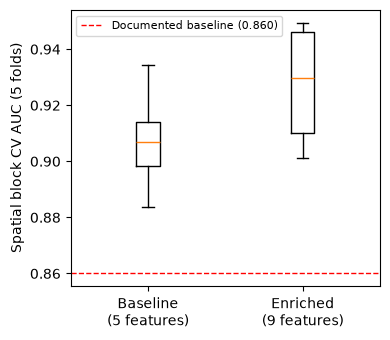

In [10]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.boxplot([baseline_aucs, enriched_aucs], tick_labels=["Baseline\n(5 features)", "Enriched\n(9 features)"])
ax.set_ylabel("Spatial block CV AUC (5 folds)")
ax.axhline(0.860, color="red", linestyle="--", linewidth=1, label="Documented baseline (0.860)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Step 7 -- Feature importance (enriched model)

If the infrastructure features (`Dist_to_Highway_m`, `Dist_to_Settlement_m`, `LULC_Friction`) show up
with real importance, that supports the sampling-bias hypothesis motivating this notebook. If they
rank near the bottom, the honest conclusion is that location favorability really is dominated by
geology/terrain, and the AUC delta above (whatever it turned out to be) is the actual answer -- not
something to keep tuning until a bigger number appears.

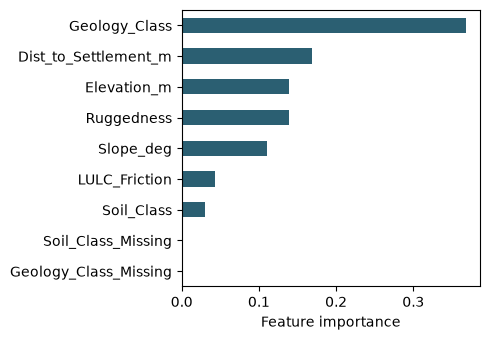

Geology_Class            0.368048
Dist_to_Settlement_m     0.169370
Elevation_m              0.139442
Ruggedness               0.139219
Slope_deg                0.110862
LULC_Friction            0.043541
Soil_Class               0.029518
Geology_Class_Missing    0.000000
Soil_Class_Missing       0.000000
dtype: float64

In [11]:
clf_full = RandomForestClassifier(n_estimators=300, min_samples_leaf=8, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1)
clf_full.fit(all_pts[ENRICHED_FEATURES].values, y)
importances = pd.Series(clf_full.feature_importances_, index=ENRICHED_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(5, 3.5))
importances.plot.barh(ax=ax, color="#2B5F72")
ax.set_xlabel("Feature importance")
plt.tight_layout()
plt.show()
importances.sort_values(ascending=False)


## Step 8 -- Save the enriched model (only if it genuinely improves on baseline)

Run this cell only after inspecting Steps 6-7 above and deciding the enriched feature set is a real,
trustworthy improvement -- not automatically. If you save a new model here, keep the old
`geosite_location_pilot_model_v2.joblib` untouched (this writes a new `_v3` filename) so the
previously-reported AUC=0.860 result remains reproducible from the existing file.

In [12]:
import joblib

SAVE = True  # flip to True once you've reviewed Steps 6-7 and decided to keep the enriched model

if SAVE:
    final_clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=8, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1)
    final_clf.fit(all_pts[ENRICHED_FEATURES].values, y)
    out_path = os.path.join(BASE, "data", "models", "geosite_location_pilot_model_v3.joblib")
    joblib.dump({"model": final_clf, "features": ENRICHED_FEATURES}, out_path)
    print("Saved:", out_path)
else:
    print("SAVE is False -- nothing written. Set SAVE=True after reviewing the AUC comparison above.")


Saved: /home/medgm/um6p-intern/geosite_project1/data/models/geosite_location_pilot_model_v3.joblib
